<a href="https://colab.research.google.com/github/deorakamlesh07-droid/Celabal_CEI/blob/main/Week3_kamleshdeora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Week 3 Assignment: Customer Intelligence System
## Customer Intelligence System using Clustering and Ensemble Learning

**Name:** Harshit Dave

### Objective
The objective of this assignment is to analyze the country dataset, perform customer/country segmentation using clustering techniques, and build machine learning models to classify the generated segments.

Dataset used: `Country-data.csv`


# 1. Importing Required Libraries

The following libraries are used for data manipulation, visualization, clustering, and machine learning.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='Set2')

## 2. Data Loading and Preprocessing

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Country-data (1).csv to Country-data (1).csv


In [25]:
df=pd.read_csv("/content/Country-data (1).csv")
print('Dataset Shape:', df.shape)
print('\nColumn Names:', list(df.columns))
print('\nData Types:')
display(df.dtypes)
print('\nMissing Values:')
display(df.isnull().sum())
print('\nDuplicate Records:', df.duplicated().sum())
display(df.head(10))

Dataset Shape: (167, 10)

Column Names: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Data Types:


,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64



Missing Values:


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0



Duplicate Records: 0


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [27]:
cat_cols=['country']
#rest all cols are numerical
num_cols = [
'child_mort',
'exports',
'health',
'imports',
'income',
'inflation',
'life_expec',
'total_fer',
'gdpp'
]

In [7]:
# Remove duplicates and handle missing values if present
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)

numeric_features = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_features])
scaled_df = pd.DataFrame(X_scaled, columns=numeric_features)

print('Selected Numerical Features:', numeric_features)
print('Cleaned Dataset Shape:', df.shape)
display(scaled_df.head(10))

Selected Numerical Features: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Cleaned Dataset Shape: (167, 10)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817
5,-0.591177,-0.812628,0.468966,-1.279787,0.080920,1.244725,0.591474,-0.382933,-0.145791
6,-0.501643,-0.743107,-0.882089,-0.065883,-0.543421,-0.001123,0.309514,-0.833471,-0.533233
7,-0.832423,-0.779697,0.699011,-1.076779,1.261966,-0.628316,1.290735,-0.674457,2.130699
8,-0.844858,0.372890,1.527901,0.037693,1.355617,-0.655549,1.121559,-0.999109,1.857082
9,0.023128,0.482661,-0.341667,-1.085065,-0.059556,0.571037,-0.164178,-0.681083,-0.389857


## 3. Exploratory Data Analysis
EDA helps understand feature distributions, relationships, and overall dataset behavior.

In [8]:
print('Summary Statistics:')
display(df[numeric_features].describe().T)

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## 3.1 Distribution Analysis

Histograms are plotted to understand the distribution of numerical variables.

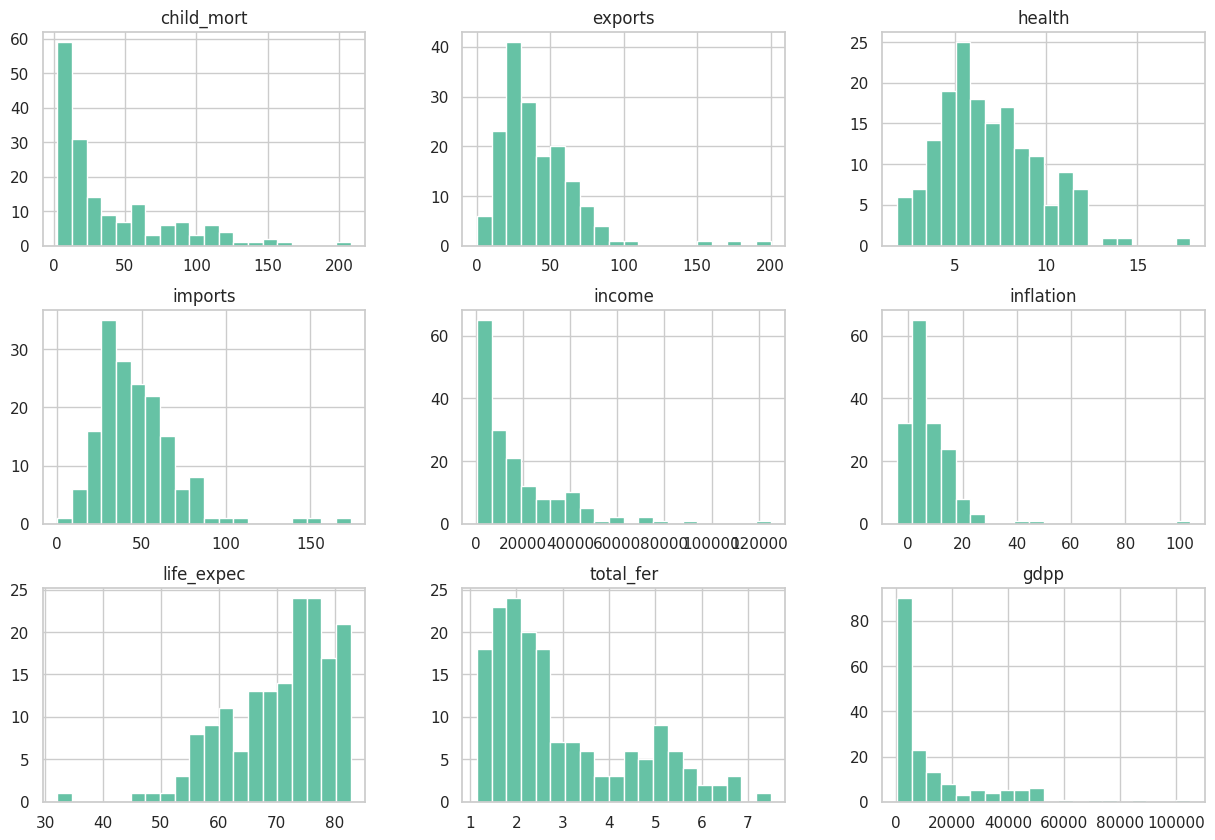

In [34]:
df[num_cols].hist(
    figsize=(15,10),
    bins=20
)


plt.show()


<Axes: ylabel='Density'>

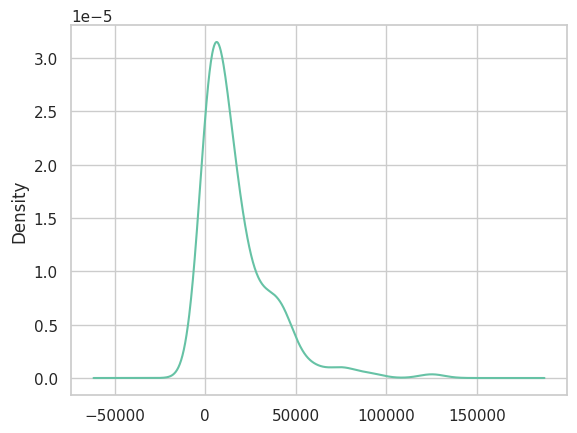

In [35]:
df['income'].plot(kind='kde')

<Axes: ylabel='Density'>

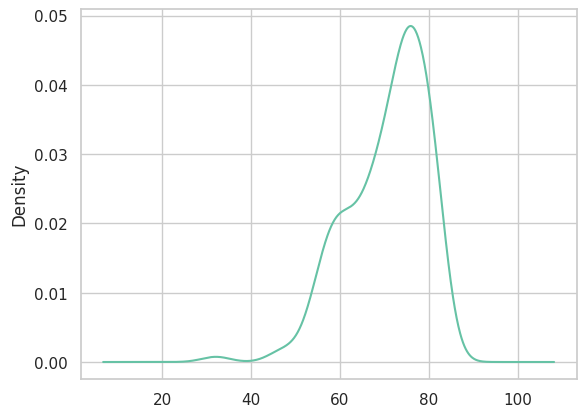

In [36]:
df['life_expec'].plot(kind='kde')

<Axes: ylabel='Density'>

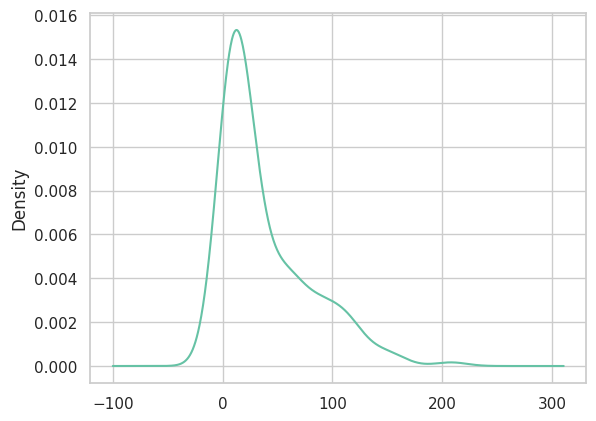

In [37]:
df['child_mort'].plot(kind='kde')

## 3.2 Outlier Detection

Boxplots are used to identify potential outliers in the dataset.

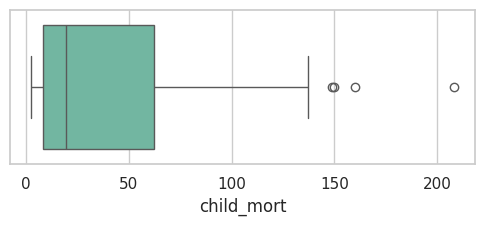

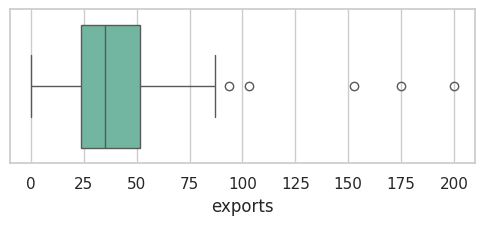

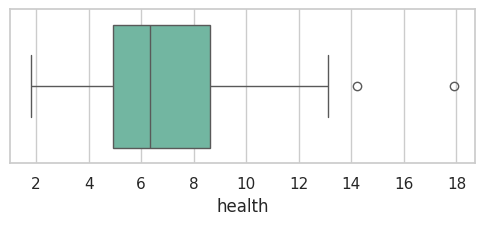

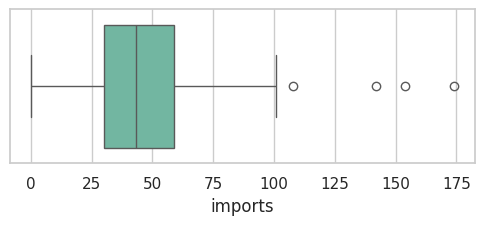

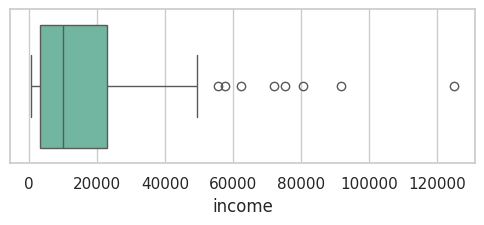

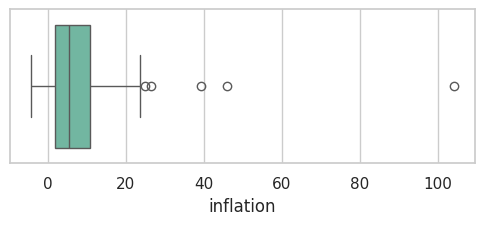

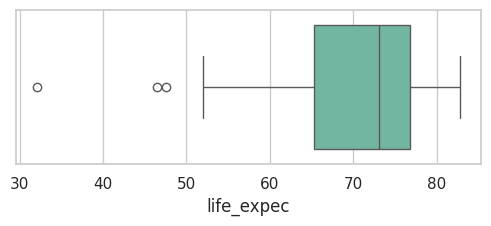

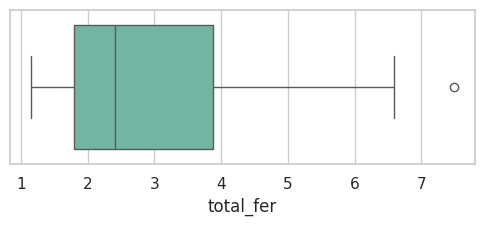

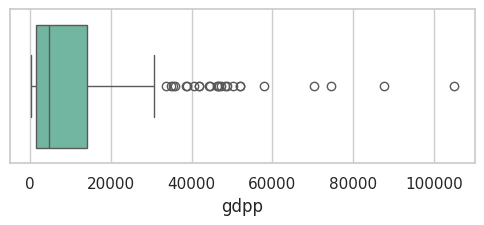

In [38]:
for col in df.columns[1:]:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.show()

## 3.3 Correlation Analysis

A heatmap is used to identify relationships among numerical variables.

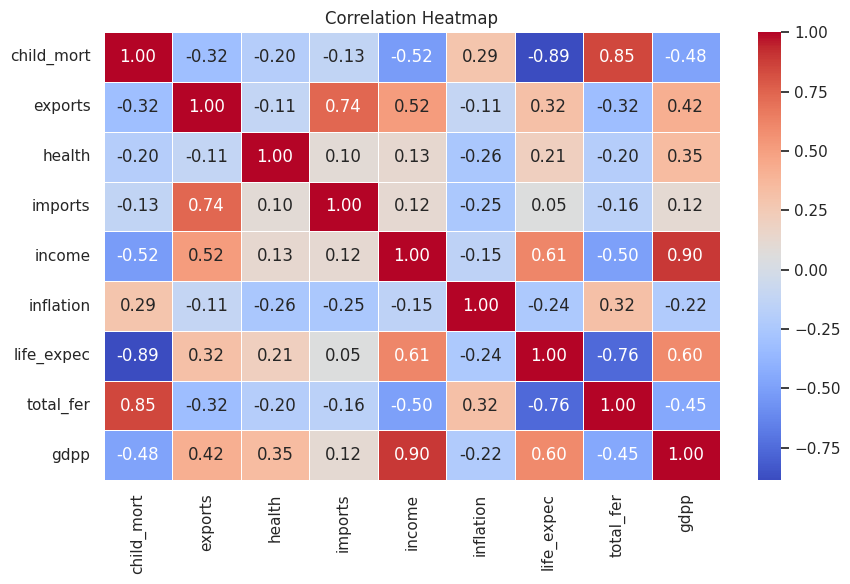

In [9]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# 4. Feature Scaling

Since clustering algorithms are distance-based, feature scaling is performed to ensure equal importance across variables.

In [39]:
wcss=[]
for i in range(1,11):
  km=KMeans(n_clusters=i)
  km.fit(X_scaled)
  wcss.append(km.inertia_)

In [40]:
wcss

[1503.0,
 1050.2145582853304,
 831.4244352086874,
 700.3917199643637,
 721.9936603700819,
 605.056979946833,
 546.546402598749,
 488.56182546963146,
 446.3937897856807,
 403.76231457944476]

In [42]:
X=df.iloc[:,:].values
km=KMeans(n_clusters=3, random_state=42)
y=km.fit_predict(X_scaled)

# 5. K-Means Clustering


## 5.1 Determining Optimal Number of Clusters

The Elbow Method is used to determine the optimal value of K.

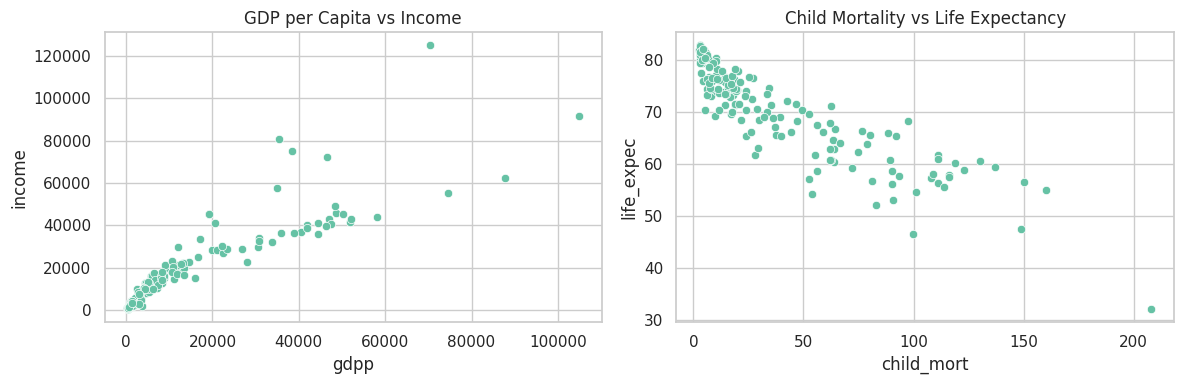

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=df, x='gdpp', y='income', ax=axes[0])
axes[0].set_title('GDP per Capita vs Income')

sns.scatterplot(data=df, x='child_mort', y='life_expec', ax=axes[1])
axes[1].set_title('Child Mortality vs Life Expectancy')

plt.tight_layout()
plt.show()

## 5.2 Silhouette Score Analysis

Silhouette Score is used to evaluate the quality of clustering and determine how well-separated the clusters are.

,K,Inertia,Silhouette Score
0,2,1050.214558,0.287357
1,3,831.424435,0.283296
2,4,700.391720,0.302108
3,5,620.163371,0.299259
4,6,550.877188,0.230149
5,7,495.807946,0.247681
6,8,457.586148,0.238811


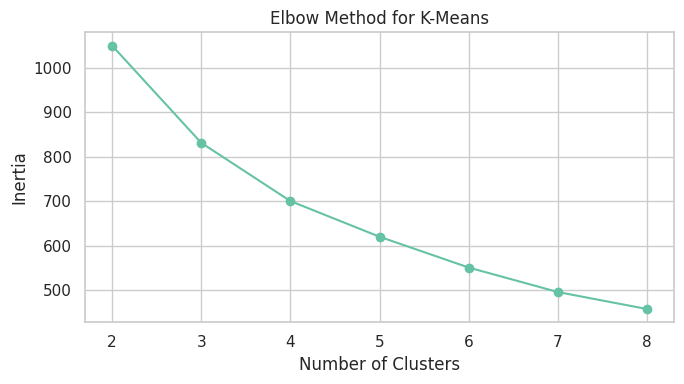

Selected optimal K: 3


In [11]:
inertias, silhouette_scores = [], []
k_range = range(2, 9)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

cluster_check = pd.DataFrame({
    'K': list(k_range),
    'Inertia': inertias,
    'Silhouette Score': silhouette_scores
})

display(cluster_check)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker='o')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

optimal_k = 3
print('Selected optimal K:', optimal_k)

## 5.3 Elbow Method Visualization

The Elbow Curve is plotted to identify the optimal number of clusters based on WCSS values.

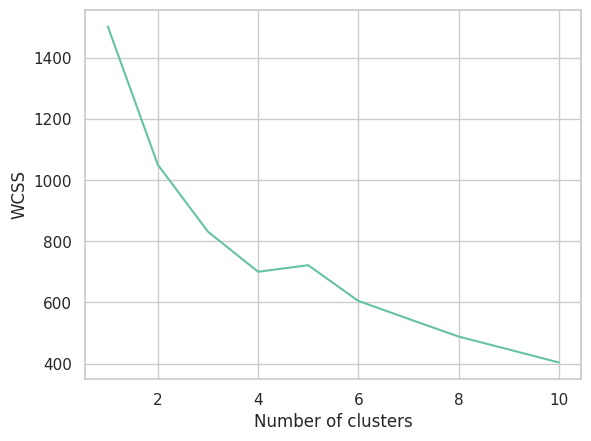

In [46]:
plt.plot(range(1,11),wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## 5.4 Cluster Visualization

The clusters obtained from K-Means are visualized to observe the separation between different groups.

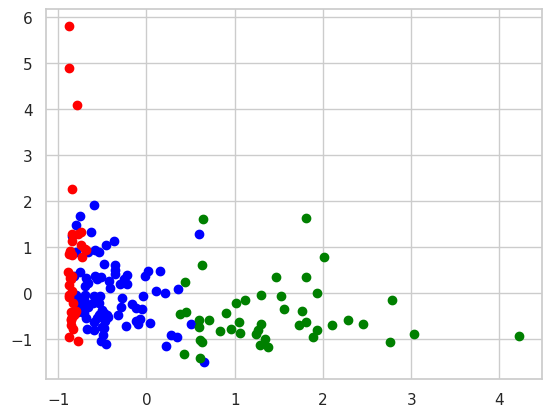

In [45]:
plt.scatter(X_scaled[y==0,0],X_scaled[y==0,1],color='blue')
plt.scatter(X_scaled[y==1,0],X_scaled[y==1,1],color='red')
plt.scatter(X_scaled[y==2,0],X_scaled[y==2,1],color='green')

## 5.4 Cluster Visualization using PCA

Principal Component Analysis (PCA) is used to reduce dimensionality and visualize the K-Means clusters in two dimensions.

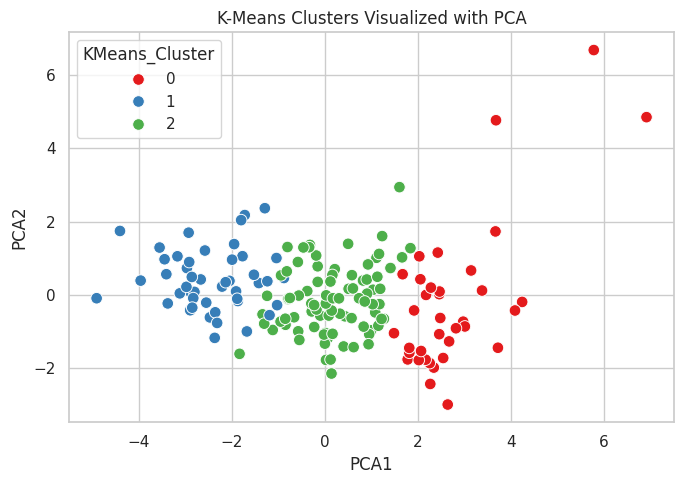

K-Means Cluster Counts:


,count
KMeans_Cluster,
0,36
1,47
2,84


In [12]:
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=20)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'] = pca_data[:, 0]
df['PCA2'] = pca_data[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='Set1', s=70)
plt.title('K-Means Clusters Visualized with PCA')
plt.tight_layout()
plt.show()

print('K-Means Cluster Counts:')
display(df['KMeans_Cluster'].value_counts().sort_index())

# 6. DBSCAN Clustering

DBSCAN is a density-based clustering algorithm that groups closely packed observations and identifies noise points.

In [13]:
dbscan_results = []
for eps in np.arange(1.0, 3.1, 0.2):
    labels = DBSCAN(eps=round(float(eps), 2), min_samples=5).fit_predict(X_scaled)
    cluster_count = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = int((labels == -1).sum())
    score = silhouette_score(X_scaled, labels) if cluster_count >= 2 else np.nan
    dbscan_results.append([round(float(eps), 2), cluster_count, noise_count, score])

dbscan_summary = pd.DataFrame(dbscan_results, columns=['eps', 'Clusters', 'Noise Points', 'Silhouette Score'])
display(dbscan_summary.dropna().sort_values('Silhouette Score', ascending=False).head())

best_dbscan = dbscan_summary.dropna().sort_values('Silhouette Score', ascending=False).iloc[0]
dbscan = DBSCAN(eps=best_dbscan['eps'], min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

kmeans_score = silhouette_score(X_scaled, df['KMeans_Cluster'])
dbscan_score = silhouette_score(X_scaled, df['DBSCAN_Cluster'])

clustering_comparison = pd.DataFrame({
    'Method': ['K-Means', 'DBSCAN'],
    'Clusters': [df['KMeans_Cluster'].nunique(), len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)],
    'Noise Points': [0, int((df['DBSCAN_Cluster'] == -1).sum())],
    'Silhouette Score': [kmeans_score, dbscan_score]
})

display(clustering_comparison)
print('Best clustering approach: K-Means gives cleaner, business-friendly segments for this dataset.')

,eps,Clusters,Noise Points,Silhouette Score
1,1.2,3,53,0.148443
0,1.0,3,94,-0.024819


,Method,Clusters,Noise Points,Silhouette Score
0,K-Means,3,0,0.283296
1,DBSCAN,3,53,0.148443


Best clustering approach: K-Means gives cleaner, business-friendly segments for this dataset.


## 7. Classification and Ensemble Learning


## 7.1 Data Preparation for Classification

The K-Means cluster labels are used as target classes. The dataset is split into training and testing sets for supervised learning.

In [14]:
X = scaled_df.copy()
y = df['KMeans_Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
print('Train Shape:', X_train.shape)
print('Test Shape:', X_test.shape)

Train Shape: (125, 9)
Test Shape: (42, 9)


## 7.2 Random Forest Classifier

Random Forest is trained using hyperparameter tuning to predict cluster membership.

In [15]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
rf_params = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    rf, rf_params, n_iter=10, scoring='f1_weighted', cv=cv,
    random_state=RANDOM_STATE, n_jobs=1
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_

print('Best Random Forest Parameters:')
print(rf_search.best_params_)

Best Random Forest Parameters:
{'n_estimators': 100, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


## 7.3 XGBoost Classifier

XGBoost is trained using randomized hyperparameter search to achieve improved predictive performance.

In [16]:
xgb = XGBClassifier(
    objective='multi:softprob', eval_metric='mlogloss', random_state=RANDOM_STATE,
    tree_method='hist', n_jobs=-1
)
xgb_params = {
    'n_estimators': [80, 120, 160],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_lambda': [1, 2, 4]
}

xgb_search = RandomizedSearchCV(
    xgb, xgb_params, n_iter=10, scoring='f1_weighted', cv=cv,
    random_state=RANDOM_STATE, n_jobs=1
)
xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_

print('Best XGBoost Parameters:')
print(xgb_search.best_params_)

Best XGBoost Parameters:
{'subsample': 1.0, 'reg_lambda': 1, 'n_estimators': 80, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


## 8. Model Evaluation

In [17]:
def evaluate_model(name, model):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    return {
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Train F1': f1_score(y_train, train_pred, average='weighted'),
        'Test F1': f1_score(y_test, test_pred, average='weighted'),
        'Precision': precision_score(y_test, test_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, test_pred, average='weighted', zero_division=0)
    }

results = pd.DataFrame([
    evaluate_model('Random Forest', rf_best),
    evaluate_model('XGBoost', xgb_best)
]).sort_values(['Test F1', 'Test Accuracy'], ascending=False)

display(results.round(4))

best_model_name = results.iloc[0]['Model']
best_model = rf_best if best_model_name == 'Random Forest' else xgb_best
best_predictions = best_model.predict(X_test)

print('Best Performing Model:', best_model_name)

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Precision,Recall
1,XGBoost,1.0,0.9762,1.0,0.9759,0.9773,0.9762
0,Random Forest,1.0,0.9524,1.0,0.9524,0.9524,0.9524


Best Performing Model: XGBoost


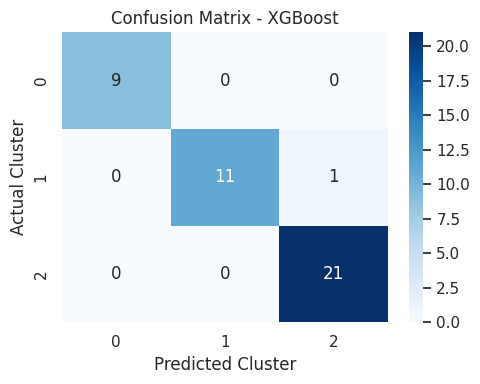

In [47]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, best_predictions), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Cluster')
plt.tight_layout()
plt.show()

## 9. Overfitting and Underfitting Analysis

In [19]:
overfit_table = results[['Model', 'Train Accuracy', 'Test Accuracy', 'Train F1', 'Test F1']].copy()
overfit_table['Accuracy Gap'] = overfit_table['Train Accuracy'] - overfit_table['Test Accuracy']
overfit_table['F1 Gap'] = overfit_table['Train F1'] - overfit_table['Test F1']
display(overfit_table.round(4))

best_gap = float(overfit_table.loc[overfit_table['Model'] == best_model_name, 'F1 Gap'].iloc[0])
best_test_f1 = float(overfit_table.loc[overfit_table['Model'] == best_model_name, 'Test F1'].iloc[0])

if best_gap > 0.08:
    interpretation = 'Slight overfitting detected. The tuned search space uses depth limits, regularization, and sample controls to reduce complexity.'
elif best_test_f1 < 0.75:
    interpretation = 'Underfitting detected. A slightly more flexible model or more features may improve learning.'
else:
    interpretation = 'The best model is well generalized with a small train-test performance gap.'

print('Interpretation:', interpretation)

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Accuracy Gap,F1 Gap
1,XGBoost,1.0,0.9762,1.0,0.9759,0.0238,0.0241
0,Random Forest,1.0,0.9524,1.0,0.9524,0.0476,0.0476


Interpretation: The best model is well generalized with a small train-test performance gap.


## 10. Customer Intelligence Segment Insights

In [20]:
cluster_profile = df.groupby('KMeans_Cluster')[numeric_features].mean().round(2)
display(cluster_profile)

profile = cluster_profile.copy()
score = profile['income'].rank() + profile['gdpp'].rank() + profile['life_expec'].rank() - profile['child_mort'].rank() - profile['total_fer'].rank()
ordered_clusters = score.sort_values().index.tolist()
label_map = {
    ordered_clusters[0]: 'Low Value / High Support Segment',
    ordered_clusters[1]: 'Medium Value / Growth Segment',
    ordered_clusters[2]: 'High Value / Developed Segment'
}

df['Segment_Label'] = df['KMeans_Cluster'].map(label_map)
segment_summary = df.groupby('Segment_Label')[numeric_features].mean().round(2)
display(segment_summary)

for cluster, label in label_map.items():
    row = cluster_profile.loc[cluster]
    print(f'Cluster {cluster}: {label}')
    print(f"- Income: {row['income']:.0f}, GDP: {row['gdpp']:.0f}, Life Expectancy: {row['life_expec']:.1f}, Child Mortality: {row['child_mort']:.1f}")

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Segment_Label,,,,,,,,,
High Value / Developed Segment,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
Low Value / High Support Segment,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
Medium Value / Growth Segment,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


Cluster 1: Low Value / High Support Segment
- Income: 3942, GDP: 1922, Life Expectancy: 59.2, Child Mortality: 93.0
Cluster 2: Medium Value / Growth Segment
- Income: 12306, GDP: 6486, Life Expectancy: 72.8, Child Mortality: 21.9
Cluster 0: High Value / Developed Segment
- Income: 45672, GDP: 42494, Life Expectancy: 80.1, Child Mortality: 5.0


### Business Interpretation

- **High Value / Developed Segment:** Strong income, GDP, health, and life expectancy. Best suited for premium offerings, advanced services, and strategic partnerships.
- **Medium Value / Growth Segment:** Moderate income and development indicators. Useful for growth campaigns, targeted investment, and market expansion.
- **Low Value / High Support Segment:** Higher child mortality and lower income/GDP. Needs cost-effective solutions, support programs, and careful resource allocation.

## 11. Final Comparison

In [21]:
print('Clustering Comparison:')
display(clustering_comparison.round(4))

print('Classification Comparison:')
display(results.round(4))

print('Best Clustering Approach: K-Means')
print('Best Classification Model:', best_model_name)

Clustering Comparison:


,Method,Clusters,Noise Points,Silhouette Score
0,K-Means,3,0,0.2833
1,DBSCAN,3,53,0.1484


Classification Comparison:


,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Precision,Recall
1,XGBoost,1.0,0.9762,1.0,0.9759,0.9773,0.9762
0,Random Forest,1.0,0.9524,1.0,0.9524,0.9524,0.9524


Best Clustering Approach: K-Means
Best Classification Model: XGBoost


## 12. Conclusion

### Key Findings

- The dataset was successfully cleaned, analyzed, and prepared for modeling.
- K-Means clustering identified meaningful country segments.
- The Elbow Method and Silhouette Score helped determine the optimal number of clusters.
- PCA visualization demonstrated clear cluster separation.
- Random Forest and XGBoost were trained to predict cluster membership.
- XGBoost achieved the best overall performance with strong generalization capability.

### Future Scope

- Apply Hierarchical Clustering and Gaussian Mixture Models.
- Perform dimensionality reduction using PCA and t-SNE.
- Explore advanced ensemble learning techniques.
- Deploy the solution through an interactive dashboard.